In [37]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import torch
import torch.nn as nn
from torch.nn import functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


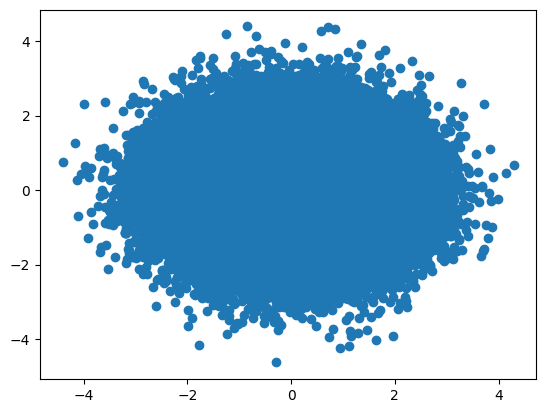

In [46]:
a = torch.randn(100000, 2, dtype=torch.float32)
x_data = a[:, 0]
y_data = a[:, 1]
x_0 = a.to(device) # noise x in time 0
plt.scatter(x_data, y_data)
plt.show()

In [49]:
moon = make_moons(n_samples=100000, noise=0.01)
moon = moon[0]
x_moon_data = moon[:, 0]
y_moon_data = moon[:, 1]
x_1 = torch.tensor(moon, dtype=torch.float32).to(device) # change tuple moon to tensor targets x_1 in time 1
print(x_1)

tensor([[ 1.0243, -0.5112],
        [ 0.0736,  0.1180],
        [ 0.4546, -0.3109],
        ...,
        [ 0.0530,  0.1434],
        [ 1.2976, -0.4601],
        [ 1.1036, -0.4922]], device='cuda:0')


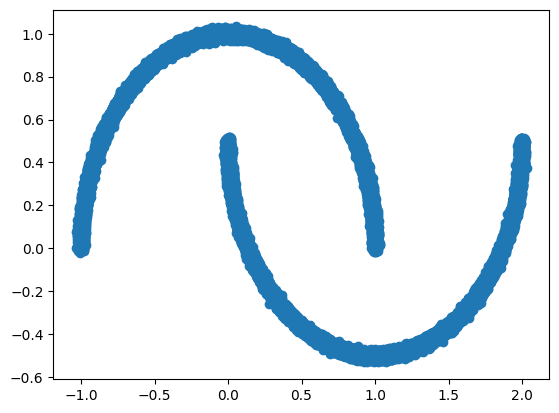

In [50]:
x = x_moon_data
y = y_moon_data
plt.scatter(x, y)
plt.show()

In [51]:
n_points, n_axis = x_0.shape
print(n_points, n_axis)

100000 2


In [52]:
class CNFs(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x) # 1000, 2
    

In [53]:
model = CNFs().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [54]:
print(x_0.shape, x_0.dtype)
print(x_1.shape, x_1.dtype)
print(next(model.parameters()).dtype)

torch.Size([100000, 2]) torch.float32
torch.Size([100000, 2]) torch.float32
torch.float32


In [ ]:
for step in range(100000):
    t = torch.rand(n_points, 1).to(device)
    x_0 = torch.randn(n_points, 2, dtype=torch.float32).to(device) # noise x in time 0
    # interpolate between x_0 and x_1
    x_t = (1-t) * x_0 + t * x_1 # 1000, 2
    # add time to x_t
    x_input = torch.cat([x_t, t], dim=1) # 1000
    x_pred = model(x_input) # 1000, 2
    target = (x_1 - x_0) # 1000, 2
    loss = F.mse_loss(x_pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 10000 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

Step 0, Loss: 1.6135


The thing model learnt is not the sepcific shape like moon, but like the velocity so we can't print the x_t directly we need to apply x_t to some random points try to get the moon

In [ ]:
for steps in range(1, 1000):
    with torch.no_grad():
        x = torch.randn(100, 2)  # start from noise
        d_t = 1/steps
        for i in range(steps):       
            t = torch.full((1000, 1), 1/steps)
            x_input = torch.cat([x, t], dim=1)
            v = model(x_input)
            x = x + v * d_t     # dt = 1/20
    if steps % 100 == 0:
        print(f"Steps: {steps}")    
        plt.scatter(x[:,0].numpy(), x[:,1].numpy())
        plt.show()
